# TEMA 4: APLICACIONES PRÁCTICAS DE VISIÓN POR COMPUTADOR

## Introducción: visión por computador vista y como encaja en sistemas para la toma de decisiones

En este punto, buscamos estudiar el tema 4 de Machine Learning II. Este tema tiene por titulo: "Aplicaciones prácticas de visión por computador". Hasta el momento nos hemos centrado en la visión del modelo y como conseguir clasificar imagenes a traves de CNN, RNN, etc. Ahora vamos a entender como funcionan los proyectos de visión por computador de verdad, no solo el entrenamiendo de la red neuronal para un problema de visión por computador. 

Recordamos que los modelos de visión por computador clasifican imágenes. Pero a su vez gracias al estudio que hicimos de los agentes y planificación sabemos que la percepción en un agente deliberativo es CLAVE. Se puede tener un modelo de visión por computador en el agente que le permita obtener información para deliberar y tomar la decisión, es decir, ACTUAR de la mejor manera posible. Evidentemente tambien puede tomar decisiones buscando un PLAN (un conjunto de acciones) en base a lo que perciba. Se ve claramente como un modelo que a priori podría parecer únicamente para clasificar empieza a tomar forma en un sistema para la toma de decisiones.

# Fundamentos del preprocesamiento en el pipeline de visión por computador con OpenCV

El pipeline en visión por computador es bastante claro y típico. Se empieza por la ADQUISICIÓN. En este punto, no entratemos tanto. Luego, por el PREPROCESAMIENTO. 

Antes de aplicar modelos avanzados, hay que preparar bien los datos.  RECORDAR GARBAGE IN-> GARBATE OUT. El preprocesamiento no puede ser deficiente ni por razones estéticas, es por razones de necesidad, ES NECESARIO, ya que el modelo puede fallar

Nos centramos en la librería OpenCV para procesar imágenes (biblioteca más extendida y robusta)

In [1]:
import cv2
# pip install opencv-python antes

## Representación imágenes digitales 

### ¿Qué es una imagen digital?

Una imagen digital es un **matriz de valores numéricos**. Cualquier operación o técnica realizada es una operación aplicada sobre esta matriz.

En cada pixel de esa matriz hay información = posición o elemento de la matriz hay información. Hay dos opciones:

- En las más simples (escala de grises)-> hay un único valor (escalar), normalmente entre 0 y 255 siendo 0 negro y 255 blanco. Los intermedios son grises. MATRIZ 2D PURA.
- En las más complejas (a colos)-> hay un vector de 3 o más componentes, que representa distintos canales de color. Vemos como ya no es un escalar, sino un vector. Por tanto, no es una matriz 2D pura, se convierte en un TENSOR DE ORDEN 3 (matriz tridimensional)


### ¿Dónde vive la matriz de la que hablábamos en memoria?

En un objeto **array**-> bloque con una secuencia de bytes y unos metadatos para que Python sepa como interpretarlo. Ejemplo de metadatos:

- shape -> Si las dimensiones del array son (alto, ancho) sabe que hay un canal de color y que es una matriz 2D pura. Si las dimensiones son (alto, ancho, canales) lo interpreta como una de las imagenes digitales complejas ya que en cada pixel hay un vector de 3 o más componentes en vez de un escalar. 

Nótese que **cv::Mat** es el equivalente en C++ -> la libreria nativa de OpenCV está escrita en C++, no en Python. Por debajo se está usando cv::Mat pero Python lo convierte automáticamente en numpy.ndarray (cv2 concretamente)

In [2]:
img = cv2.imread("data/ejemplo.jpg")

type(img)

numpy.ndarray

### ¿Cuáles son los espacios de color?

Los espacios de color más comunes en visión artificial son RGB, HSV, YCrCb y Lab.

- RGB es el más intuitivo porque es como pensamos el color de forma natural. Ejemplo para que nos lo imaginemos: tres cámaras en blanco y negro, cada una con un filtro de color delante del objetivo de la cámara-> cada foto solo registra cuanta luz de ese color había en cada punto.  Si había mucho rojo sale muy clara (pixel muy alto). Si había poco rojo, sale muy oscura (pixel muy bajo). Si las apilas (tres fotos en escala de grises) recreas la imagen a color que conoces. Si el pixel original de la imagen digital compleja es en RGB con un vector de 3 componentes (210,60,50), se ve como claramente es un pixel con rojo intenso. Si tu imagen tiene forma de tensor de orden 3, (480, 640, 3), lo que tienes en memoria son exactamente estas tres "fotos en gris" de 480×640, una detrás de otra.


- HSV, dejamos de verlo como 3 fotos de distintos colores y lo vemos como 3 fotos de distintas propiedades. H indica el tono para cada pixel (selector de color), S la saturación de ese tono (rojo más o menos intenso) y V indica el valor/brillo, es decir, que tan apagada e iluminada está la luz de nuestra imagen.

La diferencia clave entre estos dos espacios de color, es que en HSV puedes jugar con que cambiar. Por ejemplo puedes mantener el color pero le bajas la luz -> lo pones en sombra. Es decir, hemos mantenido H y S y hemos bajado la V quitando brillo a la imagen. En RGB en cambio, puedes bajar los tres números a la vez de forma rara pero para tareas de detección o segmentación no es lo mejor. 

Si de repente digo quiero detectar coches rojos, con HSV, unicamente poniendo un rango de H y S lo consigues, y V libre (coche rojo con brillo o a la sombra). Con RGB tienes que definir un rango muy amplio en los tres canales para cubrir todas las condiciones de luz posibles (el brillo esta mezclado entre los 3 canales), y ese rango tan ancho acaba solapando con otros colores parecidos, dando muchos falsos positivos (marrones o anaranjados). 

- YCrCb es un espacio de color que mezcla todo lo que hemos visto. La Y(luminancia) hace el paper de la V en HSV (brillo imagen) y está en versión blanco y negro. De hecho, una imagen en este espacio de color en Y tiene la imagen en escala de grises. 
Cr es la crominancia roja, partiendo de un gris del centro te dice cuando se desvía a rojo respecto a ese gris y cuanto se desvía a verde respecto al gris (no importa el brillo)
Cb es la crominancia azul, que es lo mismo pero con el eje azul-amarillo.

Este espacio de color también separa brillo de color pero con ejes distintos, es bueno para detectar piel, ya que la Y es muy distinta pero Cr y Cb cae siempre en la zona muy pequeña (el tono quitando brillo es muy parecido entre personas).

#### Resumen de los tres en una frase cada uno:

- RGB = tres fotos en gris, una por cada filtro de color (rojo, verde, azul).
- HSV = "¿qué color de la rueda?" + "¿qué tan puro?" + "¿qué tan brillante?"
- YCrCb = "¿qué tan brillante?" + "¿hacia el rojo o el verde?" + "¿hacia el azul o el amarillo?"

> En RGB, HSV o YCrCb, los números están pensados por motivos de hardware o de compresión — no tienen relación directa con "cuánto se nota" un cambio de color para una persona. Por ejemplo: en RGB, pasar de (5,5,5) a (15,5,5) (cerca del negro) es un salto de 10 unidades, y pasar de (240,240,240) a (250,240,240) (cerca del blanco) también es un salto de 10 unidades — pero el ojo humano percibe el primer cambio mucho más que el segundo, porque somos más sensibles a las diferencias en tonos oscuros.Lab fue diseñado para corregir eso: está construido (basándose en estudios de percepción visual humana) de forma que una misma distancia numérica representa siempre "la misma cantidad de diferencia percibida", sin importar en qué zona del espacio estés. Si dos colores están a una distancia de 2 en Lab, un humano notará una diferencia parecida tanto si esos colores son oscuros como si son claros, rojizos o verdosos.

### ¿Qué espacio de color utiliza OpenCV

OpenCV, por defecto, utiliza el orden BGR, por lo que es habitual convertir entre formatos al integrar con otras librerías. cv2.imread/cv2.imshow/cv2.imwrite hablan en BGR; todo lo demás (matplotlib, redes neuronales) habla en RGB. La conversión se hace en la frontera, justo cuando los datos "salen" de OpenCV hacia otra librería, o "entran" a OpenCV desde otra librería.


In [3]:
# por defecto lo lee en BGR

print(img.shape) # hemos visto como es una matriz tridimensional que por defecto tiene Blue Green Red

print(img[0,0]) # valor de B,G,R en el primer pixel (vector con 3 componentes en cada pixel)

(402, 800, 3)
[255 255 255]


In [4]:
# transformamos de BGR por defecto a HSV

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

H, S, V = cv2.split(hsv) # en vez de un vector con 3 componentes en cada pixel pasamos a 3 matriz 2D puras-> 3 matrices con escalares en vez de matriz tridimensional

cv2.imwrite("data/hsv/canal_H.jpg", H)
cv2.imwrite("data/hsv/canal_S.jpg", S)
cv2.imwrite("data/hsv/canal_v.jpg", V) # será la imagen en blanco y negro-> es el canal que hace referencia al brillo
 

True

### ¿Qué es una imagen binaria?

Hemos visto imágenes a color, en escala de grises y además los distintos espacios de color y sus ventajas. No obstante, hay un tipo de imagen que no hemos estudiado. La imagen binaria. En ella, cada pixel solo puede ser uno de dos valores posibles, por ejemplo 0 o 1 o 0 o 255. Tiene el shape = (alto, ancho) pero con un rango de valores reducido. Hemos ido perdiendo información, empezando a color, luego con grises con cada pixel un escalar y finalmente solo blanco o negro sin grises intermedios. Este tipo de imagense utiliza para:

- Máscaras, este pixel pertenece True/False al objeto
- Regiones de interés (ROI), este pixel está dentro de la zona que procesaré(ejempl recortes)
- Salida de segmentación, resultado final de un modelo de segmentación 

> La imagen binaria multiplicada por la original te puede apagar todo lo que es cero dejándote solo lo interesante. 

Como hemos visto, vamos perdiendo información, pero la pregunta lógica es, ¿como pasamos de una imagen en una escala de grises a una con solo 0 o 1?
Necesitas una **regla de recorte** es decir, un umbral T, de manera que un pixel >= T es 1 y que este por debajo 0. Puede ser:

- Umbral global: único valor T para toda la imagen. Funciona bien cuando toda la iluminación es uniforme
- Umbral adaptativo: mirando el promedio de la intensidad de una pequeña ventana alrededor del picel se calcula un T distinto. Puede ser necesario cuando una imagen es mas oscura que otra en general y por tanto pasar de un valor en escala de grises a uno de 0 y 1 debe adaptarse a la iluminación cambiante.

> Géron (2022) señala que, en tareas de segmentación supervisada, estas imágenes binarias se utilizan como etiquetas(LA ENTRADA DEL MODELO), por lo que su correcta generación es crítica. Si esa máscara está mal hecha, el umbral usado para generarla era global cuando debía ser adaptativo, por ejemplo, y se "comió" parte de la grieta en zonas con sombra, el modelo aprende de una etiqueta incorrecta, y no hay forma de que el entrenamiento lo compense. Por eso dice "crítica": un error aquí no es un bug que se note enseguida, es un sesgo silencioso en los propios datos de entrenamiento.

### Decisiones estratégicas de preprocesamiento

Antes de alimentar las imágenes a la red, se convierte cada fotografía de una manzana en escala de grises, se ajusta su tamaño a 224x224 píxeles y se
almacena como array de tipo float32 con valores normalizados entre 0 y 1. Estas decisiones, aunque parezcan menores, afectan directamente a la capacidad del modelo para generalizar. Lo vemos:

- Reducción de supuesto ruido: Piensa en qué distingue a una manzana roja de una manzana verde, o de un plátano, o de una naranja: en gran parte, el color. Si conviertes todo a escala de grises, una manzana roja y una manzana verde de forma idéntica pueden acabar pareciéndose mucho. Entonces has tirado a la basura precisamente la señal que más ayudaría al modelo a distinguir variedades. 

- Ajustar dimensiones: cv2.resize, y 224×224 no es un número aleatorio: es el tamaño de entrada estándar de EfficientNet-> te adaptas al modelo que vas a usar o a la resolución que necesitas

- Cambio de tipo: uint8 → float32. Recuerda que uint8 viene de la cuantización en la adquisición en el pipeline (0-255, enteros). Pero una red neuronal hace multiplicaciones de pesos y gradientes en cada eṕoca. Por tantom necesita números decimales, no enteros de 8 bits. 

- Normalización de la entrada: dividir por 255. Esto reescala el rango 0-255 → 0-1. **¿Por qué importa?** Las redes entrenan mucho mejor cuando sus entradas están en un rango pequeño y consistente. Valores grandes (hasta 255) pueden producir gradientes inestables o desproporcionados durante el entrenamiento. Dividir por 255 es la normalización más simple posible, aunque no la única: algunos modelos preentrenados (dependiendo de cómo fueron entrenados en ImageNet) esperan, en vez de [0,1], una normalización más específica (restar una media y dividir por una desviación estándar, por canal). 

> Esto conecta directamente con algo que vimos al principio de la unidad: "construir consistencia entre entrenamiento e inferencia" — si entrenas con /255 pero en producción normalizas distinto (o no normalizas), el modelo recibe datos en una "escala" que nunca vio durante el entrenamiento, y su rendimiento se degrada silenciosamente, sin ningún error. NO CORRESPONDE A COMO FUE ENTRENADA LA RED 


#### RESUMEN

"Elegir una representación adecuada desde el principio reduce errores, mejora el rendimiento de los modelos y facilita la integración con otras herramientas del pipeline"

Una imagen es un array (NumPy/cv::Mat); su representación tiene tres ejes de decisión:

- Espacio de color (RGB/HSV/YCrCb/Lab, cada uno útil para cosas distintas), 
- Nivel de información por píxel (color/grises/binaria),
- y tipo de dato + rango (uint8 0-255 vs float32 normalizado) 

In [7]:
# ver la imagen 
cv2.imshow("Mi imagen", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

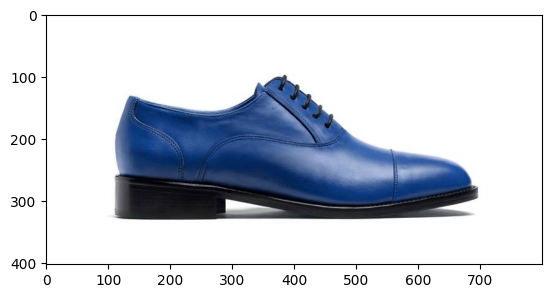

In [9]:
# usar matplotlib
import matplotlib.pyplot as plt
plt.imshow(img)

## ¿¿Qué está ocurriendo?? EFECTIVAMENTE CV2 por defecto usa BGR y estamos usando matplotlib que se espera RGB 

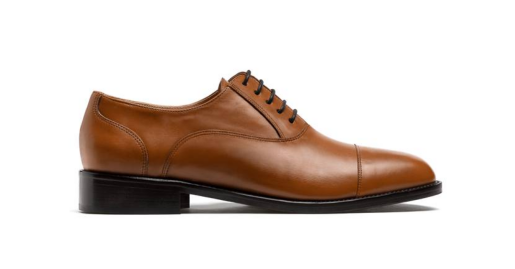

In [14]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # ahora si
plt.axis("off")
plt.show()

## Transformaciones geométricas y espaciales 

Parece que toda imagen digital que entra a un mdoelo de visión por computador debe cumplir con ciertas condiciones. Hemos dislumbrado por encima como elegiamos las dimensiones de la imagen, normalizábamos, etc. En este punto veremos todas las transformaciones geométricas que se pueden realizar con OpenCV. 

### ROTACIÓN DE UNA IMAGEN

La idea es clave: queremos girar una imagen. Normalmente queremos girarla alrededor de un punto que debería ser el centro. Para ello hay que tener en cuenta dos funciones muy importantes 

In [19]:
# obtenemos el centro
h,w = img.shape[:2]
print(f"altura: {h} y anchura: {w}")

centro = (w//2, h//2) # (x,y)-> la x hace referencia a la anchura y la y a la altura 

print(f"centro imagen {centro}") # vamos a rotar respecto a ese putno 

altura: 402 y anchura: 800
centro imagen (400, 201)


In [21]:
# algebra-> extraemos la matriz de rotacion 2D en base a ese centro con 15 grados de rotación y mismo tamaño 
M = cv2.getRotationMatrix2D(centro, 15, 1.0)

print(M)

[[  0.96592583   0.25881905 -38.39295858]
 [ -0.25881905   0.96592583 110.37652696]]


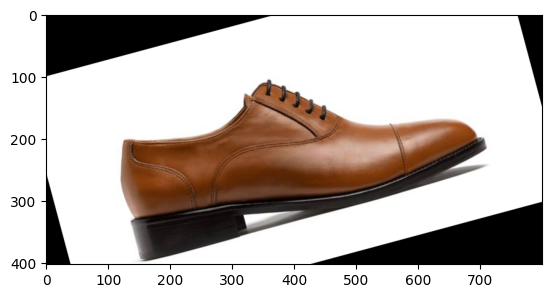

In [29]:
img_rotada = cv2.warpAffine(img, M, (w,h))

plt.imshow(cv2.cvtColor(img_rotada, cv2.COLOR_BGR2RGB))

La funcion cv2.getRotationMatrix2D() te extrae la matriz 2D de rotación dado un punto, un angulo (sentido contrario a las agujas del reloj) y una escala

Con cv2.warpAffine() aplicas la matriz de rotación sobre la imagen en sus ejes 

> Una rotación matemática pura es una matriz 2x2 y gira alrededor del origen (esquina superior-izquierda de la imagen)-> EL (0,0). Como queremos girar alrededor del centro, hace falta una columna extra (la 3ª) que compensa: LLEVA EL CENTRO AL ORIGEN, ROTA CON LOS GRADOS PUESTOS Y DEVUELVE EL CENTRO A SU SITIO. Esa columna extra es lo que convierte la matriz en 2x3. La funcion getRotationMatrix2D ya te genera la matriz de combinar esas 3 transformaciones

> warpAffine aplica esto a cada píxel: para cada coordenada (x,y) de la imagen, calcula M·(x,y,1) y obtiene la nueva posición (x',y')-> se le llama coordenadas homogéneas

### TRASLACIÓN DE UNA IMAGEN 

En este punto vamos a desplazar la imagen horizontalmente o verticalmente. Imagina que nuestra imagen no está centrada y queremos reposicionarla para la tarea de visión por computador que tenemos entre manos. Desplazamos, por tantom tx pixeles horizontal y ty pixeles vertical 

No hay una funcion para extraer la matriz pero es muy simple escribirla a mano:

In [34]:
import numpy as np

tx,ty = 50,30 

M = np.float32([[1,0,tx], [0,1,ty]]) # warpAffine exige que sea float

print(M)

[[ 1.  0. 50.]
 [ 0.  1. 30.]]


Se utiliza warpAffine(imagen, matriz, dimensiones) ya que se aplica la matriz de traslación de la misma forma que antes. Con coordenadas homogéneas nos permite trasladar la imagen multiplicando la matriz por cada coordenada de la imagen nos da directamente la nueva coordenada trasladada (x+tx, y+ty).

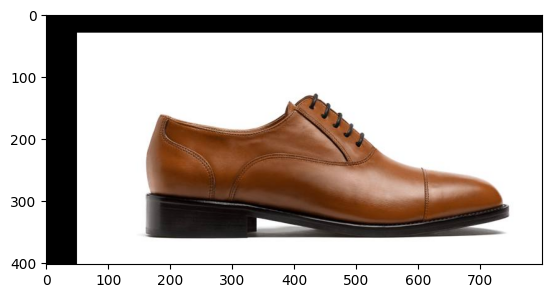

In [36]:
img_trasladada = cv2.warpAffine(img, M, (w,h))

plt.imshow(cv2.cvtColor(img_trasladada, cv2.COLOR_BGR2RGB))

### ESCALADO DE UNA IMAGEN

El escalado o resizing es la operación más común. Esto se debe a que algunas redes van a requerir un tamaño de entrada de las imágenes concretas. Imagina que estamos empleando una red ya entrenada y solo vamos a cambiar algunas capas, es decir, no entrenamos de cero. Evidentemente tenemos que adaptarnos a la entrada de como se entrenó esta red porque sino no podemos reutilizar lo que queremos. En este punto, surge una necesidad-> REDIMENSIONAR TODAS LAS IMAGENES

In [38]:
print(f"Dimensiones imagen original{img.shape}")


img_reescalada = cv2.resize(img, (224,224)) # es (ancho,alto) no lo mismo que shape que es al reves (alto,ancho,canales)

print(f"Dimensiones imagen original{img_reescalada.shape}")

Dimensiones imagen original(402, 800, 3)
Dimensiones imagen original(224, 224, 3)


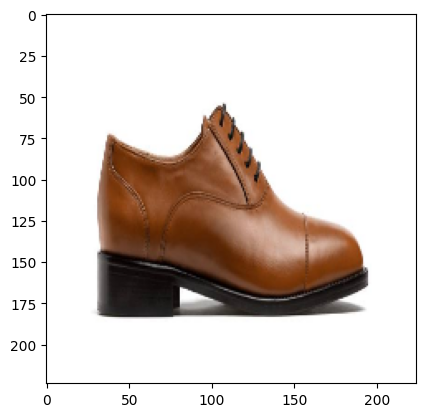

In [41]:
plt.imshow(cv2.cvtColor(img_reescalada, cv2.COLOR_RGB2BGR)) # se ha redimensionado

> interpolation (opcional): cómo calcula los píxeles nuevos. Por defecto es INTER_LINEAR pero hay mas opciones como INTER_AREA y INTER_NEAREST. la elección de uno u otro afecta al resultado: una muestra de ello es INTER_AREA suele ser mejor para reducir tamaño, mientras que INTER_CUBIC ofrece buena calidad al ampliar.

Cuando cambias el tamaño de una imagen, la nueva rejilla de píxeles no coincide con la original ya que puedes querer dimensionar a un resultado más grande o más pequeño. Por ejemplo, si reduces de 10 a 7 píxeles, el píxel nuevo nº3 "cae" en una posición intermedia entre dos píxeles originales. No hay un valor exacto ahí.

Interpolación = la regla para calcular ese valor que no existe, a partir de los píxeles originales cercanos.

Los 4 métodos principales:

- INTER_LINEAR (por defecto): mira los 4 píxeles originales más cercanos y hace un promedio ponderado según la distancia. Resultado suave. Es el equilibrio "rápido y razonable" por defecto.
- INTER_CUBIC: mira 16 píxeles vecinos y ajusta un polinomio de grado 3. Más suave que LINEAR, pero más lento. Mejor cuando agrandas la imagen (más píxeles de salida que de entrada → necesitas "inventar" más información, y cuanto más suave, mejor se ve).
- INTER_AREA: en vez de mirar puntos concretos, calcula el promedio de toda el área que cada píxel nuevo cubre sobre la imagen original. Mejor cuando reduces tamaño —> evita aliasing (patrones raros que aparecen cuando comprimes mucha información en pocos píxeles sin promediar bien).
- INTER_NEAREST: copia el valor del píxel original más cercano, sin calcular nada nuevo. Resultado "en bloques". No inventa valores —> solo los repite/elimina.

Caso especial importante: si la imagen que estás redimensionando es una máscara de segmentación (valores 0/1, etiquetas), nunca uses LINEAR/CUBIC —> promediarían un 0 y un 1 y te darían un 0.5, que no es una clase válida. Ahí usas siempre **INTER_NEAREST**, porque solo copia valores existentes, nunca inventa intermedios.

In [46]:
img_linear = cv2.resize(img, (224,224), interpolation = cv2.INTER_LINEAR) # ANALOGO A NO PONER NADA IGUAL QUE ANTES

# la estamos volviendo más pequeña comparamos con INTER_AREA

img_area= cv2.resize(img, (224,224), interpolation = cv2.INTER_AREA)

cv2.imshow("INTERPOLACION LINEAL", img_linear)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imshow("INTERPOLACION AREA", img_area)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [48]:
img_linear_grande = cv2.resize(img, (1000,1000), interpolation = cv2.INTER_LINEAR) 

# la estamos volviendo más pequeña comparamos con INTER_AREA

img_cubic = cv2.resize(img, (1000,1000), interpolation = cv2.INTER_CUBIC)

cv2.imshow("INTERPOLACION LINEAL", img_linear_grande)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imshow("INTERPOLACION CUBICA", img_cubic)
cv2.waitKey(0)
cv2.destroyAllWindows()

#### CROP RECORTE DE UNA IMAGEN

Esto es bastante intuitivo, se recorta una subregión rectangular de la imagen. Esto se hace **indexando** el array de Numpy que tienes y que se correpsonde a tu imagen digital.

Las utilidades y razones pueden ser diversas. Imagina que tienes bordes y quieres centrar el objeto que te interesa o eliminar ruido directamente de la imagen.

En la vida real, se suele usar una CNN ligera que te identifique la zona y la región, es decir, tarea de detección -> después se hace un crop o recorte solo de esa zona.


In [53]:
img.shape

(402, 800, 3)

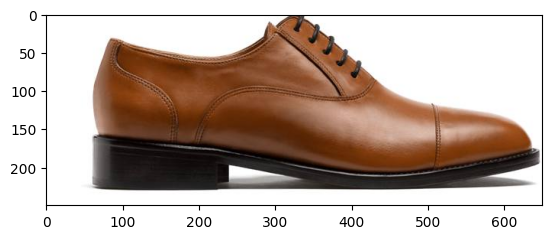

In [60]:
img_crop = img[100:350, 50:700] # altura con la que te quedas y anchura con la que te quedas, pensar en img[3,4] CONVENCIÓN DE MATRICES 

plt.imshow(cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB))

In [62]:
print(f"Shape imagen recortada {img_crop.shape[:2]}")

Shape imagen recortada (250, 650)


> Nótese la diferencia clara entre REDIMENSIONAR que manteines la imagen pero con una dimensión concreta y RECORTAR

### PADDING

Un concepto clave en toda la parte de redes neuronales para imagenes es el PADDING. Estudiado de manera superficial anteriormente pero es poco evidente. Cuando escalas una imagen o la recortas en general, podemos estar perdiendo información importante contextual. Esto se ve sobre todo cuando aplicas filtros sobre una imagen (convolución) ya que no quieres perder atención en los bordes. De la misma forma, si quieres redimensionar sin perder detalle NI DEFORMAR. Por estas razones se añaden bordes artificales para preservar la relación de aspecto o mantener su tamaño original. Normalmente en blanco y negro alrededor de la imagen. 

> Géron (2022) subraya que el uso adecuado de padding evita distorsiones en tareas como detección de objetos, donde la posición relativa del objeto en la imagen importa.

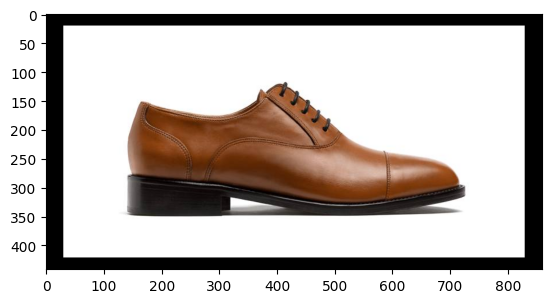

In [69]:
img_padded = cv2.copyMakeBorder(img, 20,20, 30, 30, cv2.BORDER_CONSTANT, value = (0,0,0)) # color fijo definido con value

plt.imshow(cv2.cvtColor(img_padded, cv2.COLOR_BGR2RGB))

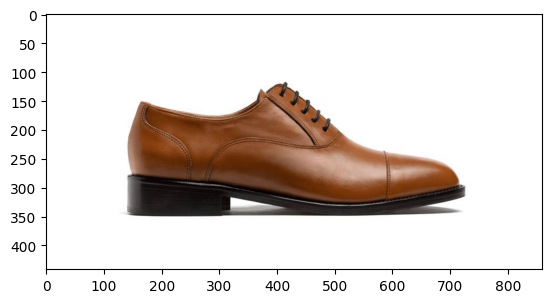

In [65]:
img_padded2 = cv2.copyMakeBorder(img, 20,20,30,30, cv2.BORDER_REPLICATE)
plt.imshow(cv2.cvtColor(img_padded2, cv2.COLOR_BGR2RGB))

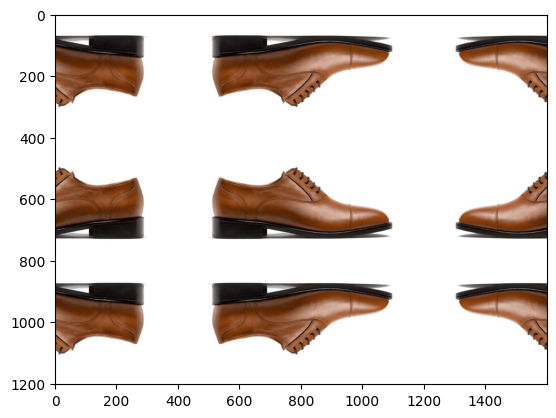

In [67]:
img_padded3 = cv2.copyMakeBorder(img, 400,400,400,400, cv2.BORDER_REFLECT)
plt.imshow(cv2.cvtColor(img_padded3, cv2.COLOR_BGR2RGB)) # REFLECTA LA IAMGEN COMO UN ESPEJO EN EL BORDE

> si vas a hacer resize después de un crop, y la región recortada no es cuadrada, el resize la deformará. Si primero le añades padding para hacerla cuadrada (sin distorsionar el contenido) y luego haces resize, evitas esa distorsión.

### DATA AUGMENTATION

Todas estas transformaciones pueden llevar a una estrategia-> data augmentation. Se generan versiones modificadas de las imagenes originales de manera que el conjunto de entrenamiento se amplia. Por ejemplo, rotaciones, volteos, escalados variables, recortes aleatorios...  Nos ayudan a que mejore la capacidad de generalización del problema.

> Gupta et al. (2022) destacan que, cuando se combinan correctamente, estas transformaciones aumentan la robustez del modelo ante cambios no vistos en producción.

LA IMAGEN NO SE VUELVE MÁS BONITA SE VUELVE MÁS UTIL ALGORÍTMICAMENTE

Utilizamos ImageDataGenerator para generar más variedad a
partir de los datos limitados disponibles.